# BESS Dispatch Analysis

This notebook runs the BESS (Battery Energy Storage System) strategy over the same period as the virtual trading backtest (Section 4 best run: `s4_n5_t30_tc10`) and analyses dispatch behaviour across six dimensions:

1. **Price & Dispatch Overlay** — DA price curve vs. MW dispatch decisions for a sample day
2. **State of Charge Tracker** — SOC evolution across the full backtest period
3. **Rebalancing Impact** — DA-committed schedule vs. final executed dispatch
4. **PnL Waterfall** — Decomposition of net PnL into DA revenue, intraday gains, imbalance costs, and degradation
5. **Summary Metrics** — Sharpe, drawdown, cycle count, and PnL decomposition
6. **Combined Equity Curve** — Virtual strategy vs. BESS cumulative PnL on a shared timeline, saved as the repository headline chart

The strategy uses LP optimisation (PuLP/HiGHS) for Day-Ahead scheduling and a three-rule intraday engine for real-time adjustments. **The DA schedule uses realised DA prices (oracle scheduling)**, which represents the theoretical upper bound on achievable BESS dispatch revenue for this asset configuration.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.bess.bess_asset import BESSAsset
from src.bess.da_optimizer import optimize_da_schedule
from src.bess.intraday_manager import run_intraday_session
from src.utils.config import load_config

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

ARTIFACT_DIR     = REPO_ROOT / "artifacts" / "da_positioning" / "s4_n5_t30_tc10"
STARTING_CAPITAL = 50_000.0

config   = load_config(REPO_ROOT / "configs" / "config.yaml")
BESS_CFG = config["bess"]

---
## Data Loading

Load the feature/price dataset and the virtual signals from the shared artifact. The analysis period is pinned to the virtual strategy's walk-forward test window so both strategies are evaluated on identical dates.

In [2]:
# Load features from the shared artifact
features_df = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
features_df["time"] = pd.to_datetime(features_df["time"], utc=True)
features_df = features_df.set_index("time").sort_index()

# Derive the analysis period from the virtual signals (walk-forward test window)
_signals = pd.read_csv(
    ARTIFACT_DIR / "virtual" / "trading" / "signals.csv",
    parse_dates=["delivery_time"],
)
_signals["delivery_time"] = pd.to_datetime(_signals["delivery_time"], utc=True)
ANALYSIS_START = _signals["delivery_time"].min()
ANALYSIS_END   = _signals["delivery_time"].max()

# Filter features to the analysis period
features_period = features_df.loc[ANALYSIS_START:ANALYSIS_END]

# Resample to hourly — BESS LP and intraday manager operate at 1-hour resolution
prices = (
    features_period[["day_ahead_price", "mid_price", "system_buy_price"]]
    .resample("1h").mean()
    .dropna()
)

# BESSAsset asset kwargs
_ASSET_FIELDS = {"capacity_mwh", "power_mw", "charge_efficiency",
                 "discharge_efficiency", "degradation_cost_per_mwh", "initial_soc_pct"}
asset_kwargs = {k: v for k, v in BESS_CFG.items() if k in _ASSET_FIELDS}

features_period_london = features_period.copy()
features_period_london.index = features_period_london.index.tz_convert("Europe/London")

print(f"Analysis period : {ANALYSIS_START.date()} → {ANALYSIS_END.date()}")
print(f"Price rows (1h) : {len(prices)}")
print(f"Feature rows    : {len(features_period)}")

Analysis period : 2018-07-21 → 2018-12-18
Price rows (1h) : 3513
Feature rows    : 7202


---
## BESS Backtest

Run the BESS pipeline day-by-day over the analysis period. The DA schedule is solved by LP against **realised DA prices** (oracle scheduling), providing the upper bound on achievable dispatch revenue. Intraday rules then execute against MID and imbalance prices in the delivery window.

In [3]:
daily_results    = []
all_dispatch_logs = []
all_da_schedules  = []

for date, day_df in prices.groupby(prices.index.date):
    n_hours = len(day_df)
    if n_hours not in {23, 24, 25}:
        continue

    # DA price schedule: use realised prices (oracle upper bound)
    da_prices   = day_df["day_ahead_price"].tolist()
    mid_prices  = day_df["mid_price"].tolist()
    imb_prices  = day_df["system_buy_price"].tolist()

    asset    = BESSAsset(**asset_kwargs)
    schedule = optimize_da_schedule(da_prices, asset)

    asset.reset()
    result = run_intraday_session(
        da_schedule=schedule,
        da_price_actual=da_prices,
        mid_prices=mid_prices,
        imbalance_prices=imb_prices,
        asset=asset,
        config=BESS_CFG,
    )

    daily_results.append({
        "date":             pd.Timestamp(date),
        "da_revenue":       result["da_revenue"],
        "intraday_pnl":     result["intraday_pnl"],
        "imbalance_pnl":    result["imbalance_pnl"],
        "degradation_cost": result["total_degradation_cost"],
        "net_pnl":          result["net_pnl"],
    })

    for entry in result["dispatch_log"]:
        entry["date"] = date
        entry["hour"] = entry["period"]
        entry["timestamp"] = day_df.index[entry["period"]]
    all_dispatch_logs.extend(result["dispatch_log"])

    for h, mw in enumerate(schedule):
        all_da_schedules.append({
            "date":      date,
            "hour":      h,
            "timestamp": day_df.index[h],
            "da_mw":     mw,
        })

results_df  = pd.DataFrame(daily_results)
dispatch_df = pd.DataFrame(all_dispatch_logs)
da_sched_df = pd.DataFrame(all_da_schedules)

print(f"Backtest complete : {len(results_df)} days")
print(f"Total net PnL     : £{results_df['net_pnl'].sum():,.0f}")
print(f"Mean daily PnL    : £{results_df['net_pnl'].mean():,.0f}")

Backtest complete : 144 days
Total net PnL     : £173,837
Mean daily PnL    : £1,207


---
## 1. BESS Strategy Showcase — Price → Dispatch → SOC

Three-panel causal chain for a representative median-spread day: the DA price signal drives the LP dispatch decision, which in turn evolves the battery state of charge. This illustrates the core BESS strategy logic — charge at low prices, discharge at high prices — on a typical (not cherry-picked) trading day.

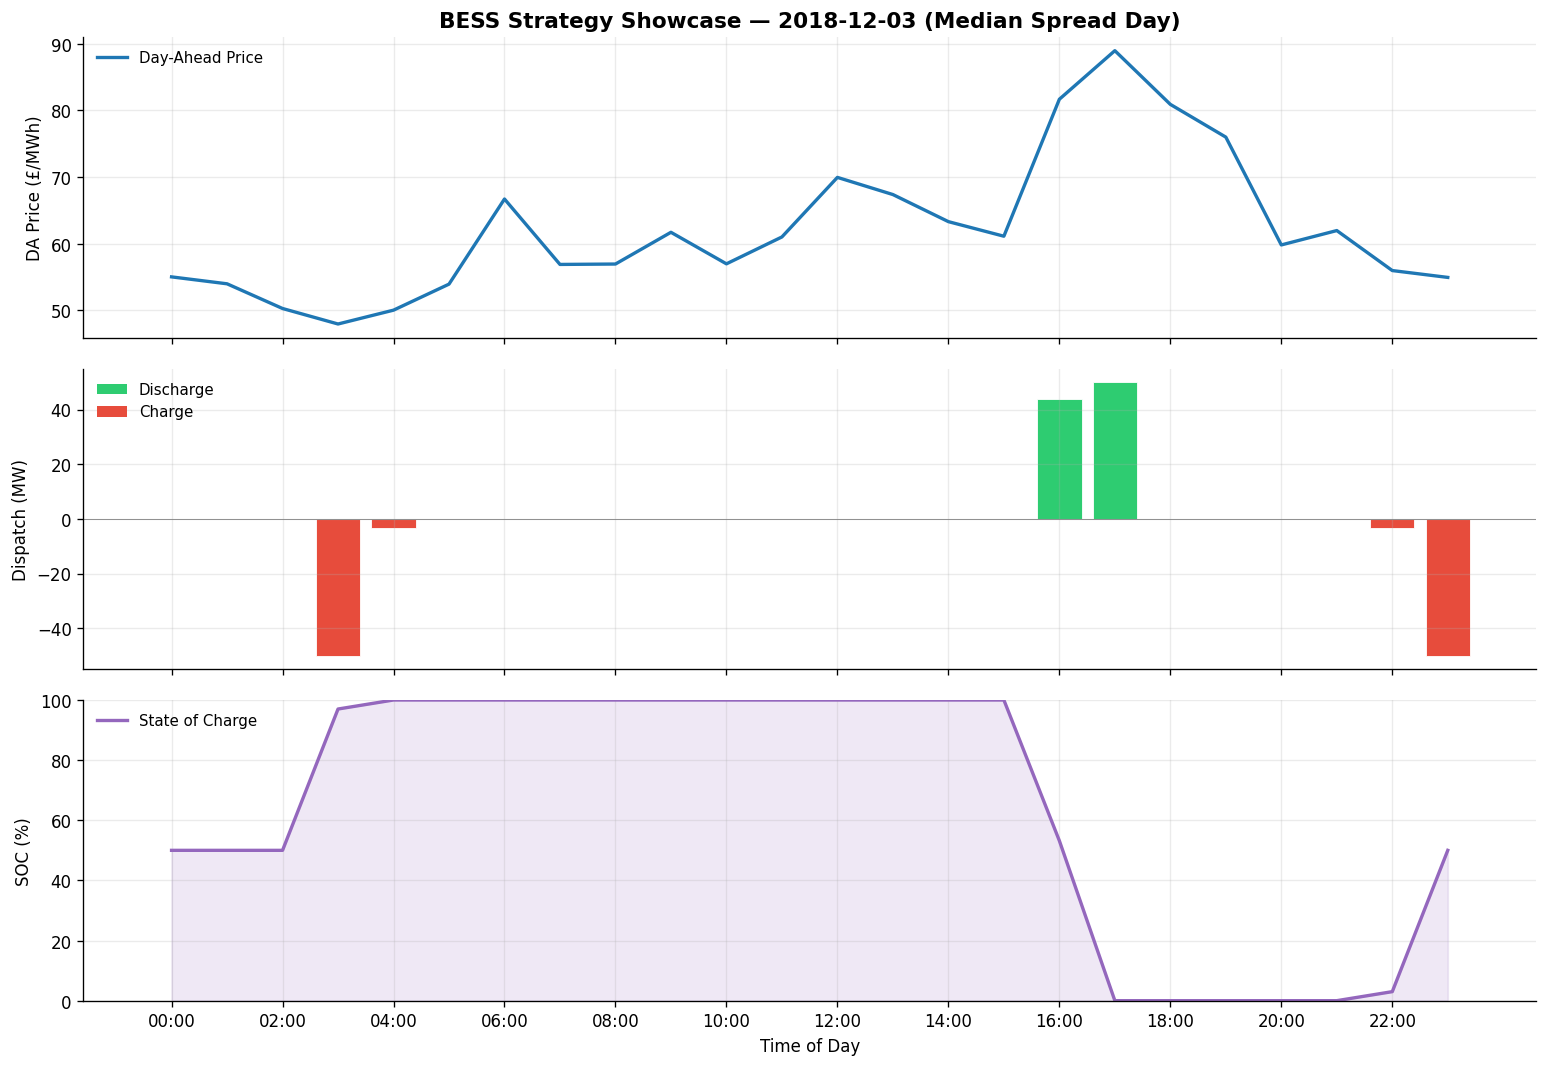

Selected day: 2018-12-03 | DA spread: £41.1/MWh (median: £40.8/MWh)


In [4]:
# Select the day with the median absolute DA spread (representative, not best)
valid_dates = set(da_sched_df["date"].unique())
mask = np.array([d in valid_dates for d in prices.index.date])
valid_prices = prices[mask]
daily_spread = valid_prices.groupby(valid_prices.index.date)["day_ahead_price"].apply(
    lambda x: x.max() - x.min()
)
median_spread = daily_spread.median()
sample_date = daily_spread.iloc[(daily_spread - median_spread).abs().argsort()[:1]].index[0]

# Extract data for the selected day
day_prices = prices.loc[prices.index.date == sample_date]
day_sched = da_sched_df[da_sched_df["date"] == sample_date].sort_values("hour")
day_dispatch = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")

da_mw = day_sched["da_mw"].values
n_hours = len(da_mw)
hours = np.arange(n_hours)

# Build SOC series from dispatch log
soc_series = day_dispatch["soc_after"].values * 100

# Time-of-day labels
time_labels = [f"{h:02d}:00" for h in hours]

# ── 3-Panel Figure ────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Panel 1: Day-Ahead Price
ax1.plot(hours, day_prices["day_ahead_price"].values[:n_hours], color="#1f77b4", linewidth=2)
ax1.set_ylabel("DA Price (£/MWh)")
ax1.set_title(f"BESS Strategy Showcase — {sample_date} (Median Spread Day)", fontsize=13, fontweight="bold")
ax1.legend(["Day-Ahead Price"], frameon=False, fontsize=9, loc="upper left")

# Panel 2: Battery Dispatch (MW)
colors = ["#2ecc71" if mw > 0 else "#e74c3c" if mw < 0 else "#cccccc" for mw in da_mw]
ax2.bar(hours, da_mw, color=colors, width=0.8, edgecolor="white", linewidth=0.5)
ax2.axhline(0, color="grey", linewidth=0.5)
ax2.set_ylabel("Dispatch (MW)")
from matplotlib.patches import Patch
ax2.legend(
    handles=[Patch(facecolor="#2ecc71", label="Discharge"), Patch(facecolor="#e74c3c", label="Charge")],
    frameon=False, fontsize=9, loc="upper left",
)

# Panel 3: State of Charge
ax3.plot(hours[:len(soc_series)], soc_series, color="#9467bd", linewidth=2)
ax3.fill_between(hours[:len(soc_series)], 0, soc_series, alpha=0.15, color="#9467bd")
ax3.set_ylim(0, 100)
ax3.set_ylabel("SOC (%)")
ax3.set_xlabel("Time of Day")
ax3.legend(["State of Charge"], frameon=False, fontsize=9, loc="upper left")

# X-axis formatting
ax3.set_xticks(hours[::2])
ax3.set_xticklabels([time_labels[i] for i in range(0, n_hours, 2)])

plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("assets/bess_strategy_showcase.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Selected day: {sample_date} | DA spread: £{daily_spread[sample_date]:.1f}/MWh (median: £{median_spread:.1f}/MWh)")

---
## 2. State of Charge (SOC) Tracker

End-of-day SOC for every day in the backtest. Because the asset resets to `initial_soc_pct` (50%) at the start of each day, this chart shows how deeply the battery is cycled within each day. Days ending well below 50% indicate net discharge; days ending above indicate the optimizer found more value in charging.

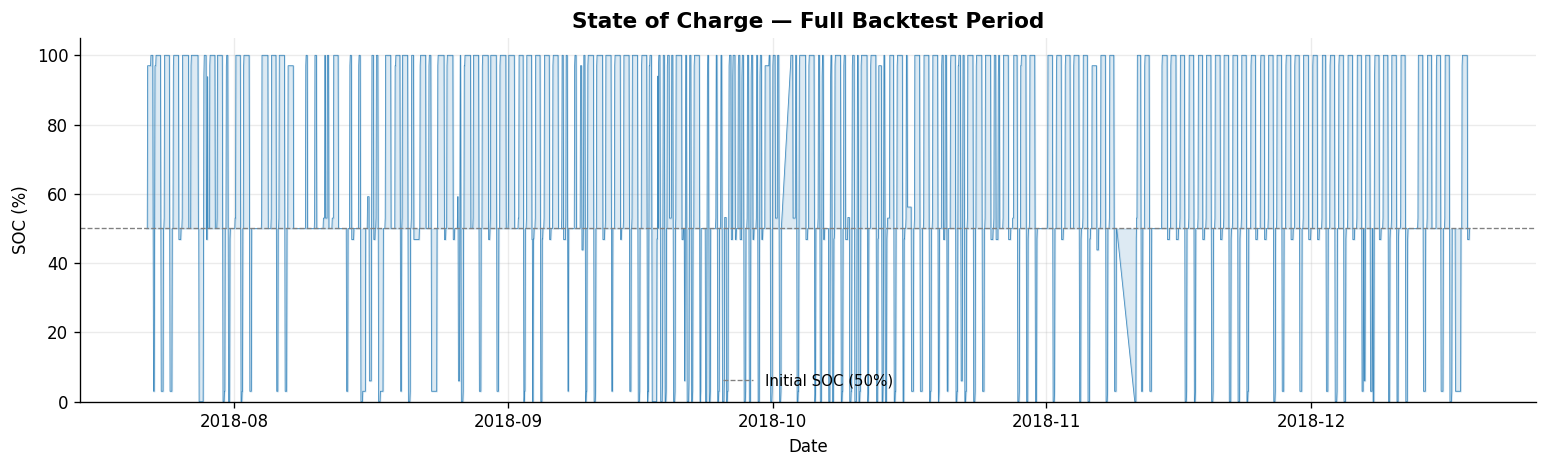

In [5]:
dispatch_df["timestamp"] = pd.to_datetime(dispatch_df["timestamp"])
soc_ts = dispatch_df.set_index("timestamp")["soc_after"].sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(soc_ts.index, soc_ts.values * 100, linewidth=0.5, color="#1f77b4", alpha=0.8)
ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Initial SOC (50%)")
ax.fill_between(soc_ts.index, soc_ts.values * 100, 50, alpha=0.15, color="#1f77b4")
ax.set_title("State of Charge — Full Backtest Period", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("SOC (%)")
ax.set_ylim(0, 105)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Rebalancing Impact — DA Schedule vs. Final Dispatch

Compares the LP-committed DA schedule with the actual dispatch (after intraday rebalancing) for the same sample day. The gap between the two series shows where the intraday rules engine adjusted volume — either to correct SOC drift or to exploit a MID spread improvement.

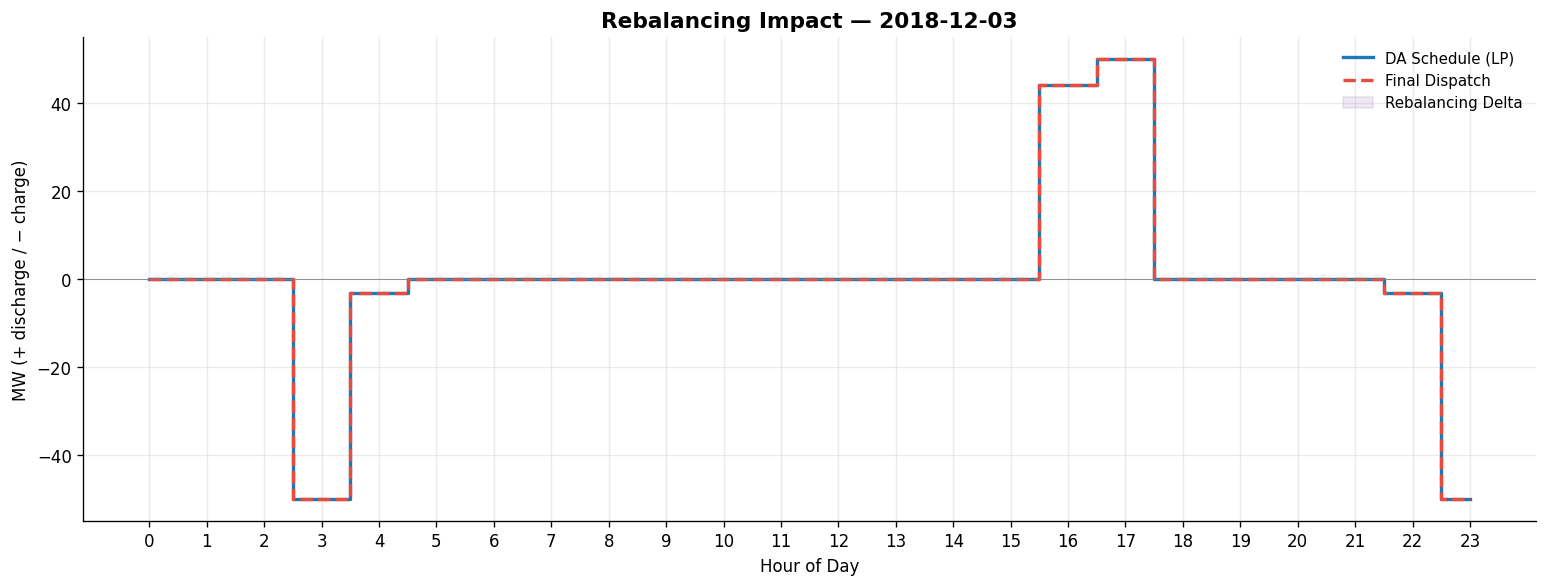

In [6]:
day_dispatch = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")

actual_mw = []
for _, row in day_dispatch.iterrows():
    if row["action"] == "discharge":
        actual_mw.append(row["mw"])
    elif row["action"] == "charge":
        actual_mw.append(-row["mw"])
    else:
        actual_mw.append(0.0)
actual_mw = np.array(actual_mw)

fig, ax = plt.subplots(figsize=(13, 5))

ax.step(hours, da_mw, where="mid", linewidth=2, color="#1f77b4", label="DA Schedule (LP)")
ax.step(hours, actual_mw, where="mid", linewidth=2, color="#e74c3c", linestyle="--", label="Final Dispatch")

ax.fill_between(hours, da_mw, actual_mw, alpha=0.15, color="#9467bd", step="mid", label="Rebalancing Delta")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MW (+ discharge / − charge)")
ax.set_title(f"Rebalancing Impact — {sample_date}", fontsize=13, fontweight="bold")
ax.set_xticks(hours)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. PnL Waterfall

Stacked decomposition of total net PnL into its four components:

- **DA Revenue** — revenue from committed Day-Ahead positions
- **Intraday PnL** — gains/losses from rebalancing trades at MID
- **Imbalance PnL** — settlement costs/credits for undelivered volume
- **Degradation Cost** — throughput-based battery wear cost (subtracted)

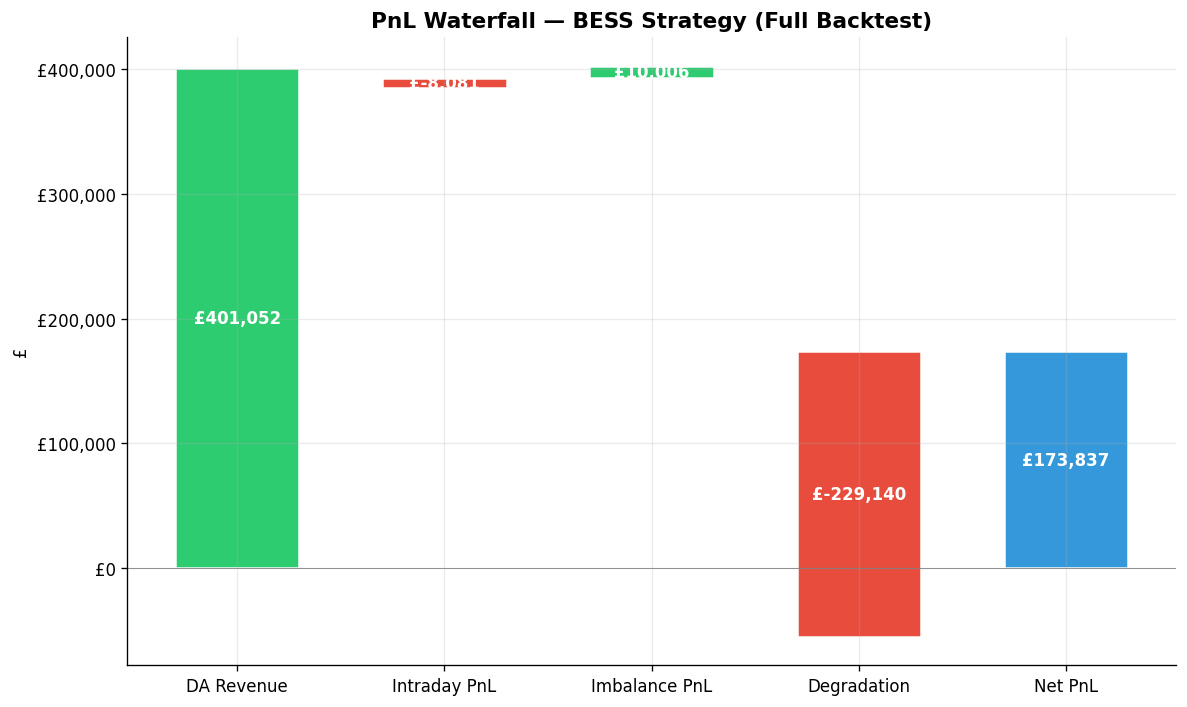

In [7]:
components = {
    "DA Revenue": results_df["da_revenue"].sum(),
    "Intraday PnL": results_df["intraday_pnl"].sum(),
    "Imbalance PnL": results_df["imbalance_pnl"].sum(),
    "Degradation": -results_df["degradation_cost"].sum(),
}
net = sum(components.values())

labels = list(components.keys()) + ["Net PnL"]
values = list(components.values()) + [net]

bottoms = []
running = 0.0
for v in list(components.values()):
    if v >= 0:
        bottoms.append(running)
        running += v
    else:
        running += v
        bottoms.append(running)
bottoms.append(0.0)

colors = []
for v in list(components.values()):
    colors.append("#2ecc71" if v >= 0 else "#e74c3c")
colors.append("#3498db")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, bottom=bottoms, color=colors, width=0.6, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, values):
    y = bar.get_y() + bar.get_height() / 2
    ax.text(bar.get_x() + bar.get_width() / 2, y, f"£{val:,.0f}",
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.set_ylabel("£")
ax.set_title("PnL Waterfall — BESS Strategy (Full Backtest)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 5. Summary Metrics

In [8]:
avg_daily = results_df["net_pnl"].mean()
std_daily = results_df["net_pnl"].std(ddof=1)
sharpe = (avg_daily / std_daily) * np.sqrt(365) if std_daily > 0 else 0.0
cumulative = results_df["net_pnl"].cumsum()
max_dd = (cumulative - cumulative.cummax()).min()

throughput = results_df["degradation_cost"].sum() / BESS_CFG["degradation_cost_per_mwh"]
total_cycles = throughput / (2 * BESS_CFG["capacity_mwh"])

summary = pd.DataFrame({
    "Metric": [
        "Total DA Revenue", "Total Intraday PnL", "Total Imbalance PnL",
        "Total Degradation Cost", "Total Net PnL",
        "Mean Daily PnL", "Sharpe Ratio", "Max Drawdown",
        "Total Equivalent Cycles", "Days Traded",
    ],
    "Value": [
        f"£{results_df['da_revenue'].sum():,.0f}",
        f"£{results_df['intraday_pnl'].sum():,.0f}",
        f"£{results_df['imbalance_pnl'].sum():,.0f}",
        f"£{results_df['degradation_cost'].sum():,.0f}",
        f"£{results_df['net_pnl'].sum():,.0f}",
        f"£{avg_daily:,.0f}",
        f"{sharpe:.3f}",
        f"£{max_dd:,.0f}",
        f"{total_cycles:.1f}",
        f"{len(results_df)}",
    ],
}).set_index("Metric")

summary.style.set_properties(**{"text-align": "right"})

,Value
Metric,
Total DA Revenue,"£401,052"
Total Intraday PnL,"£-8,081"
Total Imbalance PnL,"£10,006"
Total Degradation Cost,"£229,140"
Total Net PnL,"£173,837"
Mean Daily PnL,"£1,207"
Sharpe Ratio,20.014
Max Drawdown,£0
Total Equivalent Cycles,134.8


---
## 6. Combined Equity Curve — Virtual vs. BESS

Both strategies run over the **same period** with the same starting capital (£50,000). Virtual strategy PnL is loaded from the shared artifact (`pnl.csv`); BESS PnL is the cumulative sum of daily net results from the backtest above.

The **Combined Portfolio** line shows the total portfolio value if both strategies were funded separately from the same initial capital and run in parallel.

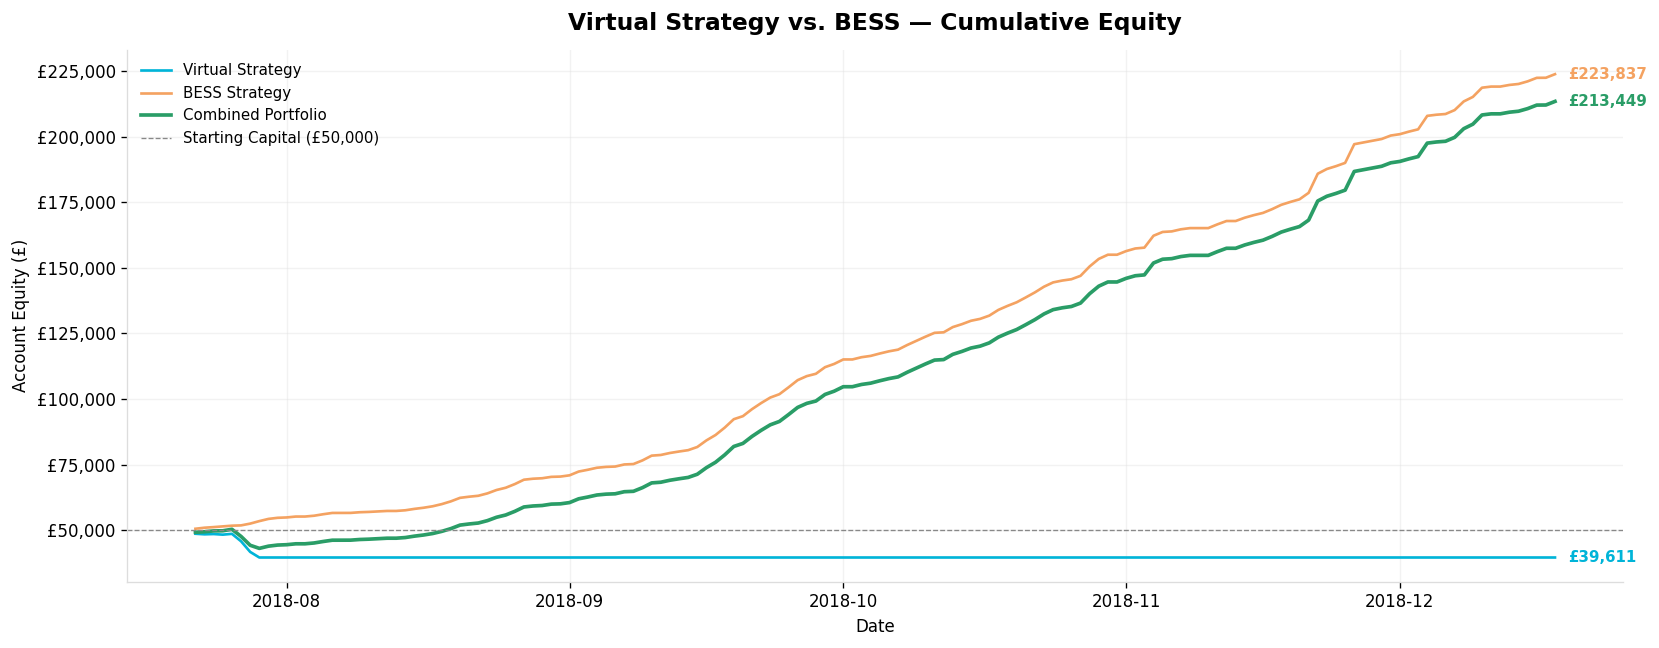


Virtual total PnL  : £-10,389  (-20.8%)
BESS total PnL     : £173,837  (+347.7%)
Combined total PnL : £163,449


In [9]:
# ── Virtual strategy PnL ──────────────────────────────────────────────────────
virt_pnl = pd.read_csv(
    ARTIFACT_DIR / "virtual" / "trading" / "pnl.csv",
    parse_dates=["time"],
)
virt_pnl["time"] = pd.to_datetime(virt_pnl["time"], utc=True)
virt_pnl["date"] = virt_pnl["time"].dt.tz_convert("Europe/London").dt.normalize()
virt_daily = virt_pnl.groupby("date")["pnl"].sum()
virt_daily.index = pd.DatetimeIndex(virt_daily.index).tz_localize(None)

# ── BESS daily PnL ────────────────────────────────────────────────────────────
bess_daily = results_df.set_index("date")["net_pnl"].copy()
bess_daily.index = pd.DatetimeIndex(bess_daily.index)

# ── Align on union of trading dates ──────────────────────────────────────────
all_dates = pd.DatetimeIndex(sorted(set(virt_daily.index) | set(bess_daily.index)))
virt_eq = STARTING_CAPITAL + virt_daily.reindex(all_dates, fill_value=0).cumsum()
bess_eq = STARTING_CAPITAL + bess_daily.reindex(all_dates, fill_value=0).cumsum()
comb_eq = STARTING_CAPITAL + (
    virt_daily.reindex(all_dates, fill_value=0) +
    bess_daily.reindex(all_dates, fill_value=0)
).cumsum()

# ── Plot ──────────────────────────────────────────────────────────────────────
COLORS_COMBINED = {
    "Virtual Strategy":          "#00b4d8",
    "BESS Strategy":             "#f4a261",
    "Combined Portfolio":        "#2a9d67",
}

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

for label, eq in [
    ("Virtual Strategy", virt_eq),
    ("BESS Strategy",    bess_eq),
    ("Combined Portfolio", comb_eq),
]:
    color = COLORS_COMBINED[label]
    lw    = 2.2 if label == "Combined Portfolio" else 1.6
    ls    = "-"
    ax.plot(eq.index, eq.values, label=label, color=color, linewidth=lw, linestyle=ls)
    ax.annotate(
        f"£{eq.iloc[-1]:,.0f}",
        xy=(eq.index[-1], eq.iloc[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        color=color,
        fontsize=9,
        fontweight="bold",
        va="center",
    )

ax.axhline(STARTING_CAPITAL, color="#888888", linestyle="--", linewidth=0.8, label=f"Starting Capital (£{STARTING_CAPITAL:,.0f})")
ax.set_title("Virtual Strategy vs. BESS — Cumulative Equity", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Account Equity (£)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.legend(frameon=False, fontsize=9, loc="upper left")

for spine in ax.spines.values():
    spine.set_color("#dddddd")
ax.grid(True, alpha=0.4, color="#e0e0e0")

plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("assets/equity_curve_combined.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nVirtual total PnL  : £{virt_daily.sum():,.0f}  ({virt_daily.sum() / STARTING_CAPITAL:+.1%})")
print(f"BESS total PnL     : £{bess_daily.sum():,.0f}  ({bess_daily.sum() / STARTING_CAPITAL:+.1%})")
print(f"Combined total PnL : £{(virt_daily.sum() + bess_daily.sum()):,.0f}")